<a href="https://colab.research.google.com/github/mishrasatyam9720-debug/customer_segmentation/blob/main/customer_segmentation_bdsnipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster  import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.datasets import make_blobs

In [23]:
df=pd.read_csv("/content/Mall_Customers[1].csv")
df.tail(n=10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [24]:
df.shape

(200, 5)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [26]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [27]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [34]:
x = df.iloc[:,[3,4]].values
scaler = StandardScaler()
scaled_x = scaler.fit_transform(x)

y = DBSCAN(eps=6, min_samples=4).fit(x_scaled)
print(y)


DBSCAN(eps=6, min_samples=4)


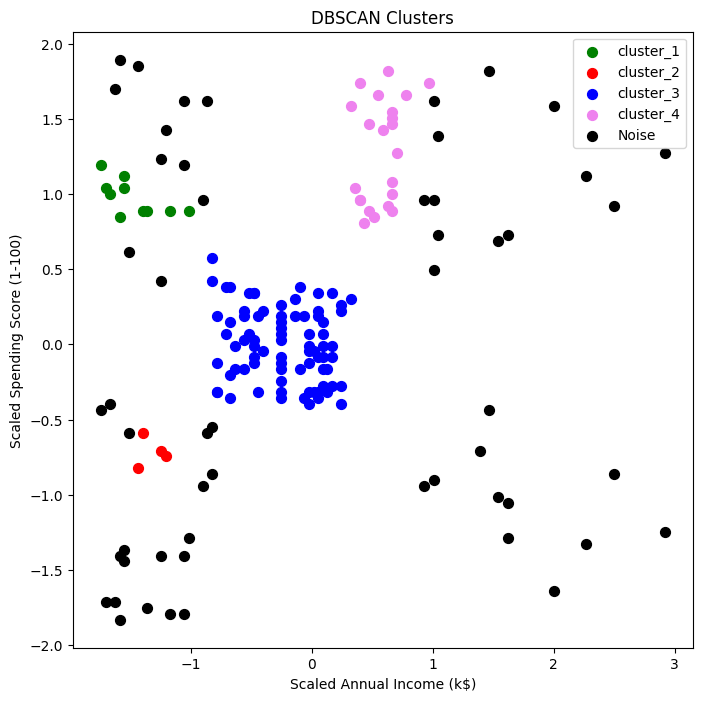

In [36]:
labels = y.labels_

plt.figure(figsize=(8,8))

plt.scatter(scaled_x[labels == 0, 0], scaled_x[labels == 0, 1],
            s=50, c="green", label="cluster_1")

plt.scatter(scaled_x[labels == 1, 0], scaled_x[labels == 1, 1],
            s=50, c="red", label="cluster_2")

plt.scatter(scaled_x[labels == 2, 0], scaled_x[labels == 2, 1],
            s=50, c="blue", label="cluster_3")

plt.scatter(scaled_x[labels == 3, 0], scaled_x[labels == 3, 1],
            s=50, c="violet", label="cluster_4")

plt.scatter(scaled_x[labels == -1, 0], scaled_x[labels == -1, 1],
            s=50, c="black", label="Noise")

plt.title("DBSCAN Clusters")

plt.xlabel("Scaled Annual Income (k$)")
plt.ylabel("Scaled Spending Score (1-100)")

plt.legend()
plt.show()